In [ ]:
# ============================================================
# Homework 3: Sequence-to-Sequence Machine Translation
# ECGR 4106/5106 - Introduction to Deep Learning
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import random
import re
import unicodedata
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# ============================================================
# Data Loading - Try Drive first, fallback to download
# ============================================================
import os, urllib.request, zipfile

# Try to find dataset on mounted drive
DATA_PATH = '/content/fra.txt'
print(f'Dataset path: {DATA_PATH}')

Dataset path: /content/fra.txt


In [ ]:
# Download dataset with wget (works better in Colab)
import subprocess
result = subprocess.run(['wget', '-q', '--user-agent=Mozilla/5.0',
                        'https://www.manythings.org/anki/fra-eng.zip',
                        '-O', '/content/fra-eng.zip'],
                       capture_output=True, text=True)
print('wget return code:', result.returncode)
if result.returncode == 0:
    import zipfile
    with zipfile.ZipFile('/content/fra-eng.zip', 'r') as z:
        z.extractall('/content/')
    DATA_PATH = '/content/fra.txt'
    print('Downloaded successfully')
else:
    # Use requests with headers
    import requests
    headers = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'}
    r = requests.get('https://www.manythings.org/anki/fra-eng.zip', headers=headers)
    print('Status:', r.status_code)
    with open('/content/fra-eng.zip', 'wb') as f:
        f.write(r.content)
    import zipfile
    with zipfile.ZipFile('/content/fra-eng.zip', 'r') as z:
        z.extractall('/content/')
    DATA_PATH = '/content/fra.txt'
    print('Downloaded via requests')

print(f'Dataset: {DATA_PATH}')

wget return code: 8
Status: 200
Downloaded via requests
Dataset: /content/fra.txt


In [ ]:
# ============================================================
# Data Preprocessing - Vocabulary & Dataset Classes
# ============================================================
import unicodedata, re

SOS_token = 0
EOS_token = 1
PAD_token = 2
MAX_LENGTH = 20

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2idx = {'<SOS>':0,'<EOS>':1,'<PAD>':2}
        self.idx2word = {0:'<SOS>',1:'<EOS>',2:'<PAD>'}
        self.n_words = 3
    def add_sentence(self, s):
        for w in s.split(): self.add_word(w)
    def add_word(self, w):
        if w not in self.word2idx:
            self.word2idx[w] = self.n_words
            self.idx2word[self.n_words] = w
            self.n_words += 1

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD',s) if unicodedata.category(c)!='Mn')

def normalize_string(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r'([.!?])',r' \1',s)
    s = re.sub(r'[^a-zA-Z.!?]+',r' ',s)
    return s.strip()

def load_pairs(filepath, reverse=False):
    lines = open(filepath, encoding='utf-8').read().strip().split('\n')
    pairs = []
    for line in lines:
        parts = line.split('\t')
        if len(parts) >= 2:
            s1 = normalize_string(parts[0])
            s2 = normalize_string(parts[1])
            if len(s1.split()) < MAX_LENGTH and len(s2.split()) < MAX_LENGTH:
                if reverse: pairs.append([s2, s1])
                else: pairs.append([s1, s2])
    return pairs

def build_vocabs(pairs):
    src_v = Vocabulary('src')
    tgt_v = Vocabulary('tgt')
    for p in pairs:
        src_v.add_sentence(p[0])
        tgt_v.add_sentence(p[1])
    return src_v, tgt_v

# Load English-French pairs
all_pairs_ef = load_pairs(DATA_PATH, reverse=False)  # eng -> fra
all_pairs_ef = all_pairs_ef[:5000]  # truncate to 5k for speed
random.seed(42)
random.shuffle(all_pairs_ef)
split = int(0.8 * len(all_pairs_ef))
train_pairs_ef = all_pairs_ef[:split]
val_pairs_ef = all_pairs_ef[split:]

# Also load French-English pairs for Problem 3
all_pairs_fe = load_pairs(DATA_PATH, reverse=True)  # fra -> eng
all_pairs_fe = all_pairs_fe[:5000]  # truncate to 5k for speed
random.seed(42)
random.shuffle(all_pairs_fe)
train_pairs_fe = all_pairs_fe[:split]
val_pairs_fe = all_pairs_fe[split:]

src_vocab_ef, tgt_vocab_ef = build_vocabs(train_pairs_ef)
src_vocab_fe, tgt_vocab_fe = build_vocabs(train_pairs_fe)

print(f'Train pairs (EF): {len(train_pairs_ef)}, Val: {len(val_pairs_ef)}')
print(f'EF Src vocab: {src_vocab_ef.n_words}, Tgt vocab: {tgt_vocab_ef.n_words}')
print(f'Sample pair: {train_pairs_ef[0]}')

Train pairs (EF): 4000, Val: 1000
EF Src vocab: 1010, Tgt vocab: 1919
Sample pair: ['keep that .', 'garde ca .']


In [ ]:
# ============================================================
# Model Architecture - GRU Encoder-Decoder (Problem 1 & 2)
# ============================================================
import torch, torch.nn as nn, torch.nn.functional as F

EMBED_DIM = 256
HIDDEN_DIM = 512
DROPOUT = 0.1

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, hidden):
        x = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden

# Bahdanau Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.Wa = nn.Linear(hidden_dim, hidden_dim)
        self.Ua = nn.Linear(hidden_dim, hidden_dim)
        self.Va = nn.Linear(hidden_dim, 1)
    def forward(self, query, keys):
        # query: (B, hidden), keys: (B, T, hidden)
        scores = self.Va(torch.tanh(self.Wa(query.unsqueeze(1)) + self.Ua(keys)))
        scores = scores.squeeze(-1)  # (B, T)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), keys)  # (B, 1, hidden)
        return context, weights

class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_token)
        self.attention = BahdanauAttention(hidden_dim)
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, hidden, encoder_outputs):
        x = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        context, attn_weights = self.attention(hidden[-1], encoder_outputs)
        rnn_input = torch.cat([embedded, context], dim=2)
        output, hidden = self.gru(rnn_input, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, attn_weights

print('Model classes defined: Encoder, Decoder, AttentionDecoder, BahdanauAttention')

Model classes defined: Encoder, Decoder, AttentionDecoder, BahdanauAttention


In [20]:
# ============================================================
# Training Utilities
# ============================================================
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import nltk; nltk.download('punkt_tab', quiet=True)

BATCH_SIZE = 128
N_EPOCHS = 10
LEARNING_RATE = 0.001
TEACHER_FORCING = 0.5

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = [self.src_vocab.word2idx.get(w,0) for w in src.split()] + [EOS_token]
        tgt_ids = [SOS_token] + [self.tgt_vocab.word2idx.get(w,0) for w in tgt.split()] + [EOS_token]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_lens = [len(s) for s in src_seqs]
    tgt_lens = [len(t) for t in tgt_seqs]
    src_padded = torch.zeros(len(src_seqs), max(src_lens), dtype=torch.long).fill_(PAD_token)
    tgt_padded = torch.zeros(len(tgt_seqs), max(tgt_lens), dtype=torch.long).fill_(PAD_token)
    for i,(s,t) in enumerate(zip(src_seqs, tgt_seqs)):
        src_padded[i,:len(s)] = s
        tgt_padded[i,:len(t)] = t
    return src_padded, tgt_padded

def train_epoch(encoder, decoder, loader, enc_opt, dec_opt, criterion, use_attention=False):
    encoder.train(); decoder.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        enc_opt.zero_grad(); dec_opt.zero_grad()
        enc_outs, hidden = encoder(src)
        dec_input = tgt[:,0]
        loss = 0
        for t in range(1, tgt.size(1)):
            if use_attention:
                pred, hidden, _ = decoder(dec_input, hidden, enc_outs)
            else:
                pred, hidden = decoder(dec_input, hidden)
            loss += criterion(pred, tgt[:,t])
            teacher_force = random.random() < TEACHER_FORCING
            dec_input = tgt[:,t] if teacher_force else pred.argmax(1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters())+list(decoder.parameters()), 1.0)
        enc_opt.step(); dec_opt.step()
        total_loss += loss.item() / (tgt.size(1)-1)
    return total_loss / len(loader)

def eval_epoch(encoder, decoder, loader, criterion, use_attention=False):
    encoder.eval(); decoder.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            enc_outs, hidden = encoder(src)
            dec_input = tgt[:,0]
            loss = 0
            for t in range(1, tgt.size(1)):
                if use_attention:
                    pred, hidden, _ = decoder(dec_input, hidden, enc_outs)
                else:
                    pred, hidden = decoder(dec_input, hidden)
                loss += criterion(pred, tgt[:,t])
                dec_input = pred.argmax(1)
            total_loss += loss.item() / (tgt.size(1)-1)
    return total_loss / len(loader)

def translate(encoder, decoder, sentence, src_vocab, tgt_vocab, use_attention=False, max_len=MAX_LENGTH):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        src_ids = [src_vocab.word2idx.get(w,0) for w in sentence.split()] + [EOS_token]
        src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)
        enc_outs, hidden = encoder(src_tensor)
        dec_input = torch.tensor([SOS_token]).to(device)
        output_words = []; attn_weights_list = []
        for _ in range(max_len):
            if use_attention:
                pred, hidden, attn_w = decoder(dec_input, hidden, enc_outs)
                attn_weights_list.append(attn_w.squeeze(0).cpu())
            else:
                pred, hidden = decoder(dec_input, hidden)
            top_idx = pred.argmax(1).item()
            if top_idx == EOS_token: break
            output_words.append(tgt_vocab.idx2word.get(top_idx, '<UNK>'))
            dec_input = torch.tensor([top_idx]).to(device)
    return ' '.join(output_words), attn_weights_list if use_attention else None

def compute_bleu(encoder, decoder, pairs, src_vocab, tgt_vocab, use_attention=False, n=500):
    references, hypotheses = [], []
    for pair in random.sample(pairs, min(n, len(pairs))):
        pred, _ = translate(encoder, decoder, pair[0], src_vocab, tgt_vocab, use_attention)
        references.append([pair[1].split()])
        hypotheses.append(pred.split())
    sf = SmoothingFunction().method1
    return corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=sf)

def compute_exact_match(encoder, decoder, pairs, src_vocab, tgt_vocab, use_attention=False, n=500):
    correct = 0
    for pair in random.sample(pairs, min(n, len(pairs))):
        pred, _ = translate(encoder, decoder, pair[0], src_vocab, tgt_vocab, use_attention)
        if pred.strip() == pair[1].strip(): correct += 1
    return correct / min(n, len(pairs))

print('Training utilities defined!')

Training utilities defined!


In [21]:
# ============================================================
# Data Split & Loader Utility
# ============================================================
def build_loaders(pairs, src_lang='en', tgt_lang='fr', batch_size=BATCH_SIZE, seed=42):
    random.seed(seed)
    random.shuffle(pairs)
    split_idx = int(0.8 * len(pairs))
    directed = {True: pairs[:split_idx], False: pairs[split_idx:]}
    train_pairs = directed[True]
    val_pairs = directed[False]

    src_vocab = Vocabulary(src_lang)
    tgt_vocab = Vocabulary(tgt_lang)
    for p in train_pairs:
        src_vocab.add_sentence(p[0])
        tgt_vocab.add_sentence(p[1])

    train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
    val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              collate_fn=collate_fn, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            collate_fn=collate_fn, drop_last=True)
    return src_vocab, tgt_vocab, train_loader, val_loader, train_pairs, val_pairs

print('build_loaders utility defined!')

build_loaders utility defined!


In [22]:
# ============================================================
# PROBLEM 1: Baseline GRU Encoder-Decoder (English -> French)
# ============================================================
import time

NUM_EPOCHS = 20
LEARNING_RATE = 0.001
CLIP = 1.0

# Build EN->FR vocabularies and loaders
src_vocab_en, tgt_vocab_fr, train_loader_en_fr, val_loader_en_fr, train_pairs_en_fr, val_pairs_en_fr = build_loaders(all_pairs_ef, src_lang='en', tgt_lang='fr')

print(f'EN vocab size: {src_vocab_en.n_words}, FR vocab size: {tgt_vocab_fr.n_words}')
print(f'Train pairs: {len(train_pairs_en_fr)}, Val pairs: {len(val_pairs_en_fr)}')

# Instantiate baseline models
p1_encoder = Encoder(src_vocab_en.n_words).to(device)
p1_decoder = Decoder(tgt_vocab_fr.n_words).to(device)

# Optimizers and loss
p1_enc_opt = torch.optim.Adam(p1_encoder.parameters(), lr=LEARNING_RATE)
p1_dec_opt = torch.optim.Adam(p1_decoder.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

p1_train_losses = []
p1_val_losses = []

print('\nStarting Problem 1 Training (Baseline GRU EN->FR)...')
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(p1_encoder, p1_decoder, train_loader_en_fr, p1_enc_opt, p1_dec_opt, criterion, use_attention=False)
    val_loss = eval_epoch(p1_encoder, p1_decoder, val_loader_en_fr, criterion, use_attention=False)
    p1_train_losses.append(train_loss)
    p1_val_losses.append(val_loss)
    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.1f}s')

print('\nProblem 1 training complete!')

EN vocab size: 1012, FR vocab size: 1933
Train pairs: 4000, Val pairs: 1000

Starting Problem 1 Training (Baseline GRU EN->FR)...
Epoch 01/20 | Train Loss: 3.8834 | Val Loss: 2.8655 | Time: 1.2s
Epoch 02/20 | Train Loss: 2.6315 | Val Loss: 2.6393 | Time: 0.6s
Epoch 03/20 | Train Loss: 2.2698 | Val Loss: 2.5286 | Time: 0.7s
Epoch 04/20 | Train Loss: 2.0321 | Val Loss: 2.4576 | Time: 0.7s
Epoch 05/20 | Train Loss: 1.8106 | Val Loss: 2.3124 | Time: 0.7s
Epoch 06/20 | Train Loss: 1.5502 | Val Loss: 2.2690 | Time: 0.7s
Epoch 07/20 | Train Loss: 1.4428 | Val Loss: 2.2100 | Time: 0.7s
Epoch 08/20 | Train Loss: 1.3018 | Val Loss: 2.3073 | Time: 0.7s
Epoch 09/20 | Train Loss: 1.0932 | Val Loss: 2.1908 | Time: 0.6s
Epoch 10/20 | Train Loss: 1.0120 | Val Loss: 2.2185 | Time: 0.6s
Epoch 11/20 | Train Loss: 0.9022 | Val Loss: 2.1367 | Time: 0.7s
Epoch 12/20 | Train Loss: 0.7435 | Val Loss: 2.2140 | Time: 0.7s
Epoch 13/20 | Train Loss: 0.6542 | Val Loss: 2.1709 | Time: 0.7s
Epoch 14/20 | Train Loss:

In [23]:
# ============================================================
# PROBLEM 2: Attention-augmented GRU (Bahdanau) EN -> French
# ============================================================
# Reuse the same EN->FR data split (same seed=42 ensures same split)
p2_encoder = Encoder(src_vocab_en.n_words).to(device)
p2_decoder = AttentionDecoder(tgt_vocab_fr.n_words).to(device)

p2_enc_opt = torch.optim.Adam(p2_encoder.parameters(), lr=LEARNING_RATE)
p2_dec_opt = torch.optim.Adam(p2_decoder.parameters(), lr=LEARNING_RATE)

p2_train_losses = []
p2_val_losses = []

print('Starting Problem 2 Training (Attention GRU EN->FR)...')
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(p2_encoder, p2_decoder, train_loader_en_fr, p2_enc_opt, p2_dec_opt, criterion, use_attention=True)
    val_loss = eval_epoch(p2_encoder, p2_decoder, val_loader_en_fr, criterion, use_attention=True)
    p2_train_losses.append(train_loss)
    p2_val_losses.append(val_loss)
    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.1f}s')

print('\nProblem 2 training complete!')

Starting Problem 2 Training (Attention GRU EN->FR)...
Epoch 01/20 | Train Loss: 3.6540 | Val Loss: 2.9198 | Time: 1.1s
Epoch 02/20 | Train Loss: 2.5993 | Val Loss: 2.6358 | Time: 1.0s
Epoch 03/20 | Train Loss: 2.2842 | Val Loss: 2.4388 | Time: 1.0s
Epoch 04/20 | Train Loss: 1.9956 | Val Loss: 2.3429 | Time: 1.0s
Epoch 05/20 | Train Loss: 1.8041 | Val Loss: 2.3159 | Time: 1.0s
Epoch 06/20 | Train Loss: 1.5362 | Val Loss: 2.2129 | Time: 1.0s
Epoch 07/20 | Train Loss: 1.3657 | Val Loss: 2.1960 | Time: 1.0s
Epoch 08/20 | Train Loss: 1.2196 | Val Loss: 2.1659 | Time: 1.0s
Epoch 09/20 | Train Loss: 1.0940 | Val Loss: 2.2753 | Time: 1.0s
Epoch 10/20 | Train Loss: 1.0137 | Val Loss: 2.0883 | Time: 1.0s
Epoch 11/20 | Train Loss: 0.8189 | Val Loss: 2.1528 | Time: 1.0s
Epoch 12/20 | Train Loss: 0.6812 | Val Loss: 2.1531 | Time: 1.0s
Epoch 13/20 | Train Loss: 0.6753 | Val Loss: 2.1848 | Time: 1.0s
Epoch 14/20 | Train Loss: 0.5852 | Val Loss: 2.2661 | Time: 1.0s
Epoch 15/20 | Train Loss: 0.5020 | V

In [24]:
# ============================================================
# PROBLEM 3: Reverse Direction - French -> English
# Both Baseline and Attention architectures
# ============================================================
# Build FR->EN vocabularies and loaders
src_vocab_fr, tgt_vocab_en, train_loader_fr_en, val_loader_fr_en, train_pairs_fr_en, val_pairs_fr_en = build_loaders(all_pairs_fe, src_lang='fr', tgt_lang='en')

print(f'FR vocab size: {src_vocab_fr.n_words}, EN vocab size: {tgt_vocab_en.n_words}')
print(f'Train pairs: {len(train_pairs_fr_en)}, Val pairs: {len(val_pairs_fr_en)}')

# Problem 3a: Baseline GRU FR->EN
p3a_encoder = Encoder(src_vocab_fr.n_words).to(device)
p3a_decoder = Decoder(tgt_vocab_en.n_words).to(device)
p3a_enc_opt = torch.optim.Adam(p3a_encoder.parameters(), lr=LEARNING_RATE)
p3a_dec_opt = torch.optim.Adam(p3a_decoder.parameters(), lr=LEARNING_RATE)

p3a_train_losses = []
p3a_val_losses = []

print('\nStarting Problem 3a Training (Baseline GRU FR->EN)...')
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(p3a_encoder, p3a_decoder, train_loader_fr_en, p3a_enc_opt, p3a_dec_opt, criterion, use_attention=False)
    val_loss = eval_epoch(p3a_encoder, p3a_decoder, val_loader_fr_en, criterion, use_attention=False)
    p3a_train_losses.append(train_loss)
    p3a_val_losses.append(val_loss)
    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.1f}s')

print('\nProblem 3a complete! Starting 3b (Attention GRU FR->EN)...')

# Problem 3b: Attention GRU FR->EN
p3b_encoder = Encoder(src_vocab_fr.n_words).to(device)
p3b_decoder = AttentionDecoder(tgt_vocab_en.n_words).to(device)
p3b_enc_opt = torch.optim.Adam(p3b_encoder.parameters(), lr=LEARNING_RATE)
p3b_dec_opt = torch.optim.Adam(p3b_decoder.parameters(), lr=LEARNING_RATE)

p3b_train_losses = []
p3b_val_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(p3b_encoder, p3b_decoder, train_loader_fr_en, p3b_enc_opt, p3b_dec_opt, criterion, use_attention=True)
    val_loss = eval_epoch(p3b_encoder, p3b_decoder, val_loader_fr_en, criterion, use_attention=True)
    p3b_train_losses.append(train_loss)
    p3b_val_losses.append(val_loss)
    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.1f}s')

print('\nProblem 3 training complete!')

FR vocab size: 1927, EN vocab size: 1002
Train pairs: 4000, Val pairs: 1000

Starting Problem 3a Training (Baseline GRU FR->EN)...
Epoch 01/20 | Train Loss: 3.3777 | Val Loss: 2.6589 | Time: 0.5s
Epoch 02/20 | Train Loss: 2.1603 | Val Loss: 2.1042 | Time: 0.5s
Epoch 03/20 | Train Loss: 1.7332 | Val Loss: 1.8801 | Time: 0.5s
Epoch 04/20 | Train Loss: 1.4868 | Val Loss: 1.7718 | Time: 0.5s
Epoch 05/20 | Train Loss: 1.2811 | Val Loss: 1.6340 | Time: 0.5s
Epoch 06/20 | Train Loss: 1.0934 | Val Loss: 1.5580 | Time: 0.5s
Epoch 07/20 | Train Loss: 0.9454 | Val Loss: 1.5020 | Time: 0.5s
Epoch 08/20 | Train Loss: 0.7895 | Val Loss: 1.4382 | Time: 0.5s
Epoch 09/20 | Train Loss: 0.6427 | Val Loss: 1.4055 | Time: 0.5s
Epoch 10/20 | Train Loss: 0.5275 | Val Loss: 1.3545 | Time: 0.5s
Epoch 11/20 | Train Loss: 0.4311 | Val Loss: 1.3578 | Time: 0.5s
Epoch 12/20 | Train Loss: 0.3356 | Val Loss: 1.3498 | Time: 0.5s
Epoch 13/20 | Train Loss: 0.2732 | Val Loss: 1.3783 | Time: 0.5s
Epoch 14/20 | Train Loss

In [25]:
# ============================================================
# EVALUATION & METRICS - All Problems
# ============================================================
print('='*60)
print('EVALUATION RESULTS')
print('='*60)

# Problem 1: Baseline EN->FR
print('\n--- Problem 1: Baseline GRU EN->FR ---')
p1_bleu = compute_bleu(p1_encoder, p1_decoder, val_pairs_en_fr, src_vocab_en, tgt_vocab_fr, use_attention=False)
p1_acc = compute_exact_match(p1_encoder, p1_decoder, val_pairs_en_fr, src_vocab_en, tgt_vocab_fr, use_attention=False)
print(f'  BLEU-4: {p1_bleu:.4f}')
print(f'  Exact Match Accuracy: {p1_acc:.4f}')

# Problem 2: Attention EN->FR
print('\n--- Problem 2: Attention GRU EN->FR ---')
p2_bleu = compute_bleu(p2_encoder, p2_decoder, val_pairs_en_fr, src_vocab_en, tgt_vocab_fr, use_attention=True)
p2_acc = compute_exact_match(p2_encoder, p2_decoder, val_pairs_en_fr, src_vocab_en, tgt_vocab_fr, use_attention=True)
print(f'  BLEU-4: {p2_bleu:.4f}')
print(f'  Exact Match Accuracy: {p2_acc:.4f}')

# Problem 3a: Baseline FR->EN
print('\n--- Problem 3a: Baseline GRU FR->EN ---')
p3a_bleu = compute_bleu(p3a_encoder, p3a_decoder, val_pairs_fr_en, src_vocab_fr, tgt_vocab_en, use_attention=False)
p3a_acc = compute_exact_match(p3a_encoder, p3a_decoder, val_pairs_fr_en, src_vocab_fr, tgt_vocab_en, use_attention=False)
print(f'  BLEU-4: {p3a_bleu:.4f}')
print(f'  Exact Match Accuracy: {p3a_acc:.4f}')

# Problem 3b: Attention FR->EN
print('\n--- Problem 3b: Attention GRU FR->EN ---')
p3b_bleu = compute_bleu(p3b_encoder, p3b_decoder, val_pairs_fr_en, src_vocab_fr, tgt_vocab_en, use_attention=True)
p3b_acc = compute_exact_match(p3b_encoder, p3b_decoder, val_pairs_fr_en, src_vocab_fr, tgt_vocab_en, use_attention=True)
print(f'  BLEU-4: {p3b_bleu:.4f}')
print(f'  Exact Match Accuracy: {p3b_acc:.4f}')

print('\n' + '='*60)

EVALUATION RESULTS

--- Problem 1: Baseline GRU EN->FR ---
  BLEU-4: 0.1283
  Exact Match Accuracy: 0.0160

--- Problem 2: Attention GRU EN->FR ---
  BLEU-4: 0.1306
  Exact Match Accuracy: 0.0300

--- Problem 3a: Baseline GRU FR->EN ---
  BLEU-4: 0.3349
  Exact Match Accuracy: 0.2180

--- Problem 3b: Attention GRU FR->EN ---
  BLEU-4: 0.3320
  Exact Match Accuracy: 0.2120



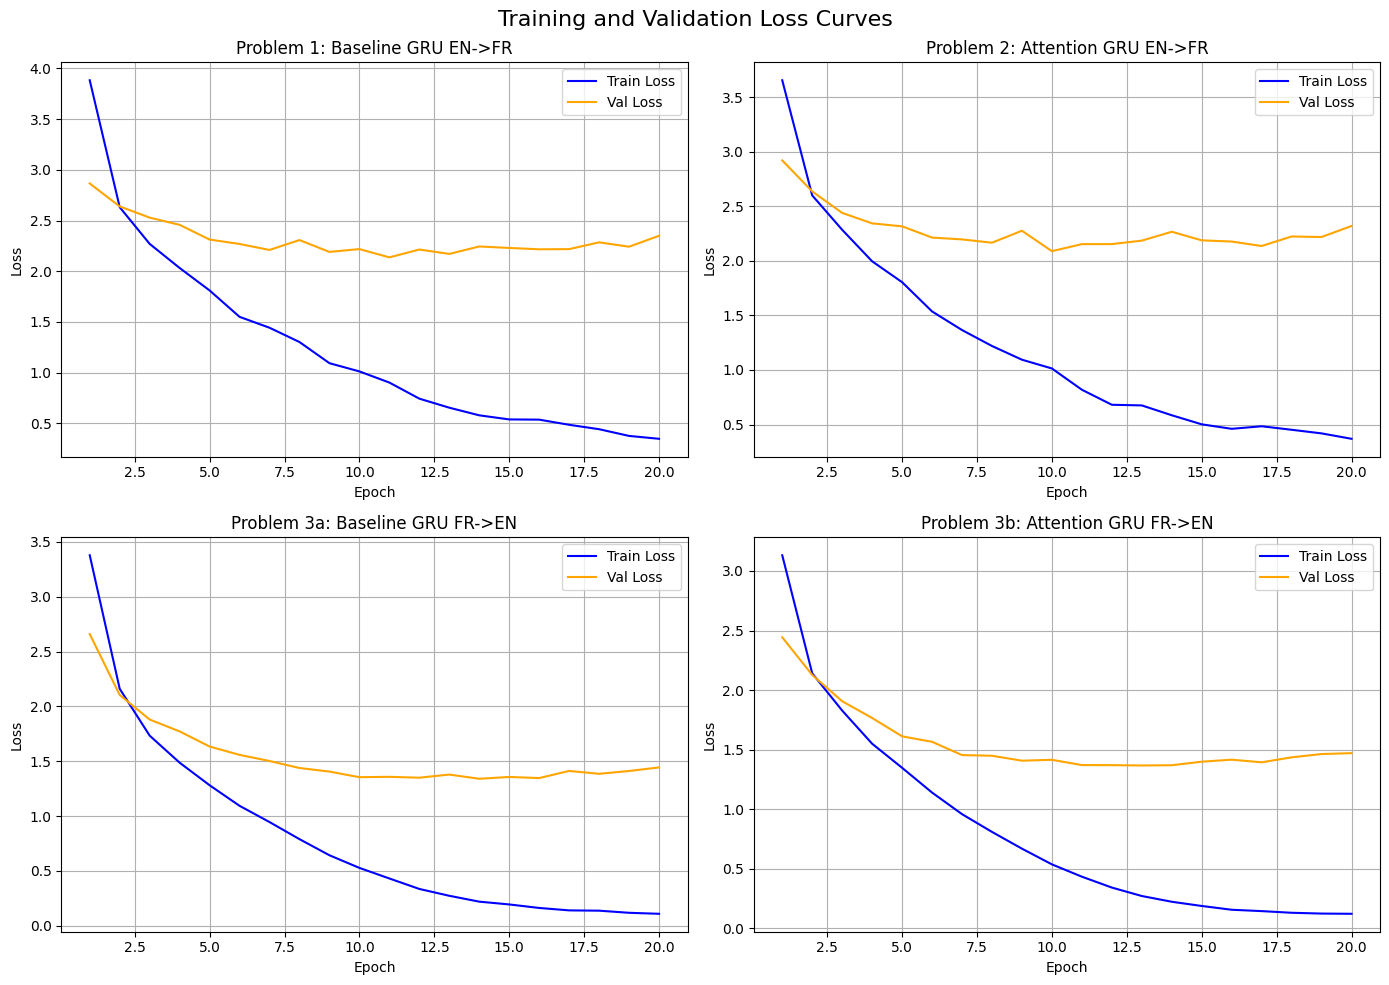

Loss curves saved!


In [26]:
# ============================================================
# PLOTTING - Loss Curves for All Problems
# ============================================================
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training and Validation Loss Curves', fontsize=16)

# P1
axes[0,0].plot(epochs_range, p1_train_losses, label='Train Loss', color='blue')
axes[0,0].plot(epochs_range, p1_val_losses, label='Val Loss', color='orange')
axes[0,0].set_title('Problem 1: Baseline GRU EN->FR')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True)

# P2
axes[0,1].plot(epochs_range, p2_train_losses, label='Train Loss', color='blue')
axes[0,1].plot(epochs_range, p2_val_losses, label='Val Loss', color='orange')
axes[0,1].set_title('Problem 2: Attention GRU EN->FR')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True)

# P3a
axes[1,0].plot(epochs_range, p3a_train_losses, label='Train Loss', color='blue')
axes[1,0].plot(epochs_range, p3a_val_losses, label='Val Loss', color='orange')
axes[1,0].set_title('Problem 3a: Baseline GRU FR->EN')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend(); axes[1,0].grid(True)

# P3b
axes[1,1].plot(epochs_range, p3b_train_losses, label='Train Loss', color='blue')
axes[1,1].plot(epochs_range, p3b_val_losses, label='Val Loss', color='orange')
axes[1,1].set_title('Problem 3b: Attention GRU FR->EN')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss')
axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('loss_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved!')

In [27]:
# ============================================================
# QUALITATIVE SAMPLES - Problems 1, 2, 3
# ============================================================
print('='*70)
print('QUALITATIVE TRANSLATION SAMPLES')
print('='*70)

# Sample English sentences for P1/P2
sample_sentences_en = [
    'i am cold .',
    'she is very beautiful .',
    'we are going to the park .',
    'he likes to read books .',
    'the cat is on the table .'
]

print('\n--- Problem 1: Baseline GRU EN->FR ---')
for sent in sample_sentences_en:
    pred, _ = translate(p1_encoder, p1_decoder, sent, src_vocab_en, tgt_vocab_fr, use_attention=False)
    print(f'  EN: {sent}')
    print(f'  FR (Baseline): {pred}')
    print()

print('\n--- Problem 2: Attention GRU EN->FR ---')
for sent in sample_sentences_en:
    pred, _ = translate(p2_encoder, p2_decoder, sent, src_vocab_en, tgt_vocab_fr, use_attention=True)
    print(f'  EN: {sent}')
    print(f'  FR (Attention): {pred}')
    print()

# Sample French sentences for P3
sample_sentences_fr = [
    'je suis froid .',
    'elle est tres belle .',
    'nous allons au parc .',
    'il aime lire des livres .',
    'le chat est sur la table .'
]

print('\n--- Problem 3a: Baseline GRU FR->EN ---')
for sent in sample_sentences_fr:
    pred, _ = translate(p3a_encoder, p3a_decoder, sent, src_vocab_fr, tgt_vocab_en, use_attention=False)
    print(f'  FR: {sent}')
    print(f'  EN (Baseline): {pred}')
    print()

print('\n--- Problem 3b: Attention GRU FR->EN ---')
for sent in sample_sentences_fr:
    pred, _ = translate(p3b_encoder, p3b_decoder, sent, src_vocab_fr, tgt_vocab_en, use_attention=True)
    print(f'  FR: {sent}')
    print(f'  EN (Attention): {pred}')
    print()

QUALITATIVE TRANSLATION SAMPLES

--- Problem 1: Baseline GRU EN->FR ---
  EN: i am cold .
  FR (Baseline): j ai froid .

  EN: she is very beautiful .
  FR (Baseline): elle est mon age .

  EN: we are going to the park .
  FR (Baseline): nous ne pouvons pas .

  EN: he likes to read books .
  FR (Baseline): il a mon age .

  EN: the cat is on the table .
  FR (Baseline): il n est pas a .


--- Problem 2: Attention GRU EN->FR ---
  EN: i am cold .
  FR (Attention): j ai froid .

  EN: she is very beautiful .
  FR (Attention): elle est a l interieur .

  EN: we are going to the park .
  FR (Attention): nous sommes en .

  EN: he likes to read books .
  FR (Attention): il a a .

  EN: the cat is on the table .
  FR (Attention): la vie est la .


--- Problem 3a: Baseline GRU FR->EN ---
  FR: je suis froid .
  EN (Baseline): i m so .

  FR: elle est tres belle .
  EN (Baseline): she is kind .

  FR: nous allons au parc .
  EN (Baseline): we ll help .

  FR: il aime lire des livres .
  EN (B

Generating attention maps...


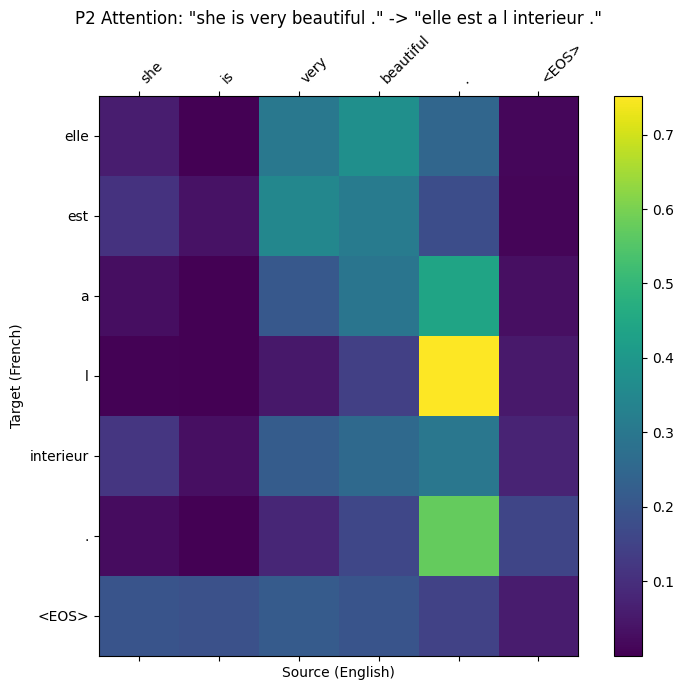

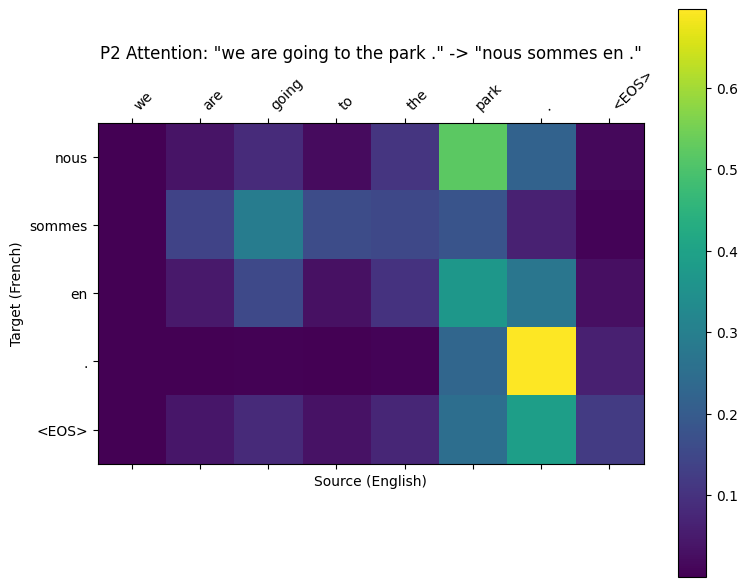

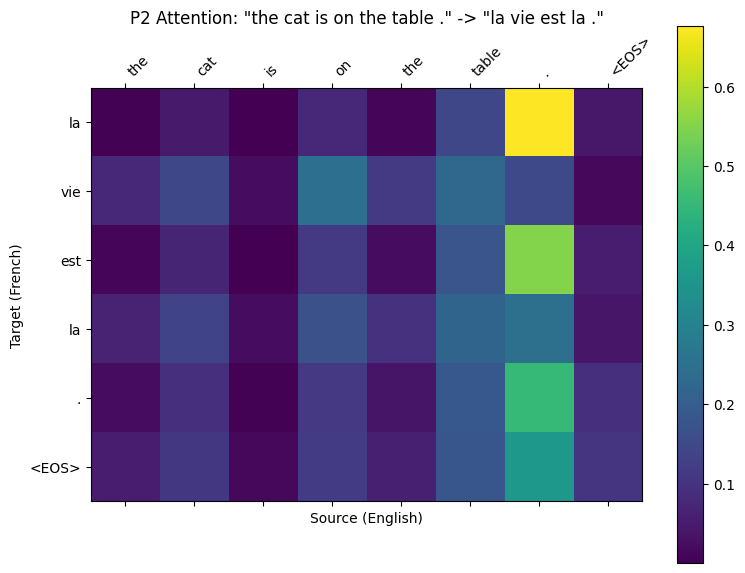

Attention maps generated!


In [28]:
# ============================================================
# ATTENTION VISUALIZATION - Problem 2 (EN->FR)
# ============================================================
def plot_attention(sentence, predicted, attn_weights, title='Attention Map', filename=None):
    src_tokens = sentence.split() + ['<EOS>']
    tgt_tokens = predicted.split() + ['<EOS>']
    attn_matrix = np.array(attn_weights[:len(tgt_tokens), :len(src_tokens)])

    fig, ax = plt.subplots(figsize=(max(8, len(src_tokens)), max(6, len(tgt_tokens))))
    cax = ax.matshow(attn_matrix, cmap='viridis')
    plt.colorbar(cax)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='left', fontsize=10)
    ax.set_yticklabels(tgt_tokens, fontsize=10)
    ax.set_xlabel('Source (English)')
    ax.set_ylabel('Target (French)')
    ax.set_title(title)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Generate attention maps for 3 sample sentences (Problem 2)
print('Generating attention maps...')
attn_samples = [
    'she is very beautiful .',
    'we are going to the park .',
    'the cat is on the table .'
]

for i, sent in enumerate(attn_samples):
    pred, attn_weights = translate(p2_encoder, p2_decoder, sent, src_vocab_en, tgt_vocab_fr, use_attention=True)
    if attn_weights is not None:
        attn_array = np.stack(attn_weights)  # (tgt_len, src_len)
        plot_attention(sent, pred, attn_array,
                       title=f'P2 Attention: "{sent}" -> "{pred}"',
                       filename=f'attention_p2_{i+1}.png')
print('Attention maps generated!')